# Ames Housing Complete Lab
Uses the Kaggle `train.csv` (Ames Housing) dataset. The Ames dataset contains 79 explanatory variables and the target `SalePrice`. citeturn0search0turn0search1

In [6]:
# !pip install xgboost joblib -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib,json

from sklearn.model_selection import train_test_split,KFold,cross_validate,GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

SEED=42


## Step 1 - Load Dataset

In [7]:
from google.colab import files

uploaded = files.upload()

import pandas as pd

df = pd.read_csv('train.csv')
target = 'SalePrice'

display(df.head())
print(df.shape)

Saving train.csv to train (1).csv


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


(1460, 81)


## Step 2 - Data Audit

In [8]:
display(df.describe(include='all'))
audit=pd.DataFrame({'dtype':df.dtypes.astype(str),
'missing':df.isna().sum(),
'missing_pct':100*df.isna().mean(),
'unique':df.nunique()})
display(audit.sort_values('missing_pct',ascending=False).head(30))
print(df.duplicated().sum())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


,dtype,missing,missing_pct,unique
PoolQC,object,1453,99.520548,3
MiscFeature,object,1406,96.301370,4
Alley,object,1369,93.767123,2
Fence,object,1179,80.753425,4
MasVnrType,object,872,59.726027,3
FireplaceQu,object,690,47.260274,5
LotFrontage,float64,259,17.739726,110
GarageQual,object,81,5.547945,5
GarageFinish,object,81,5.547945,3
GarageType,object,81,5.547945,6


0


## Step 3 - Train Test Split

In [9]:
X=df.drop(columns=[target,'Id'])
y=df[target]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=SEED)

## Step 4 - EDA

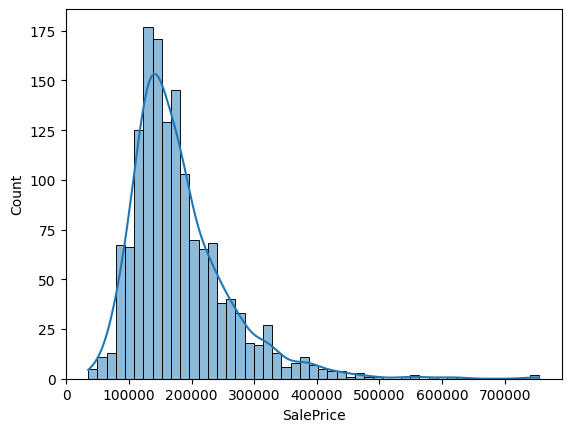

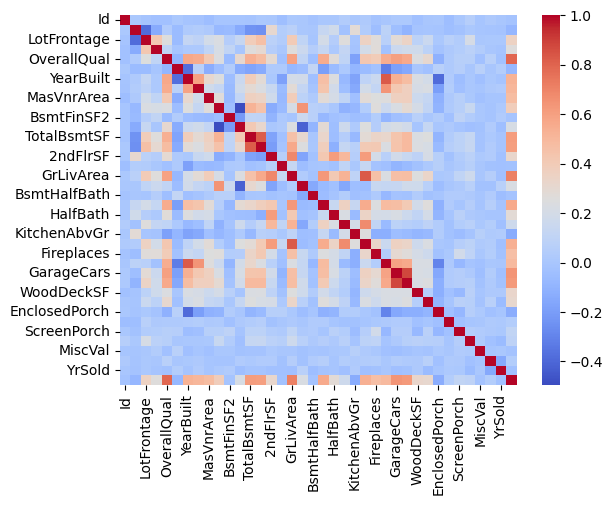

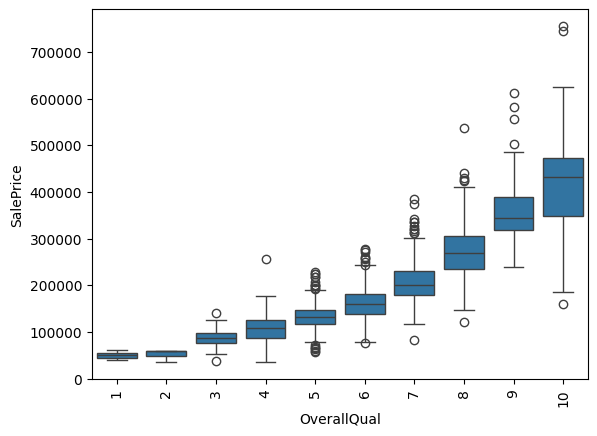

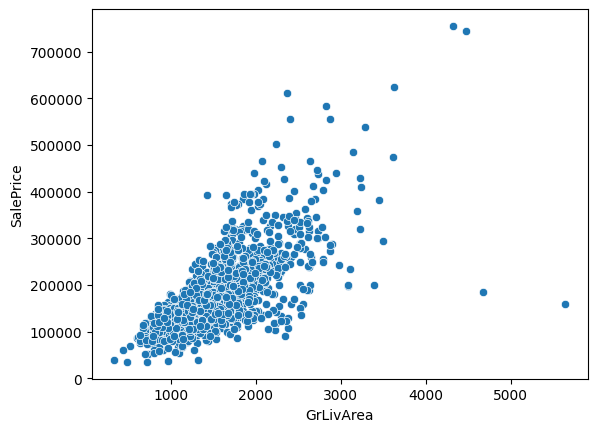

In [10]:
sns.histplot(y,kde=True);plt.show()
sns.heatmap(df.select_dtypes(include=np.number).corr(),cmap='coolwarm');plt.show()
sns.boxplot(x='OverallQual',y='SalePrice',data=df);plt.xticks(rotation=90);plt.show()
sns.scatterplot(x='GrLivArea',y='SalePrice',data=df);plt.show()

## Step 5 - Preprocessing

In [11]:
num=X_train.select_dtypes(include=np.number).columns
cat=X_train.select_dtypes(exclude=np.number).columns
preprocess=ColumnTransformer([
('num',Pipeline([('imp',SimpleImputer(strategy='median')),('sc',StandardScaler())]),num),
('cat',Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('oh',OneHotEncoder(handle_unknown='ignore'))]),cat)
])

## Step 6 - Baseline

In [12]:
dummy=DummyRegressor()
dummy.fit(X_train[num],y_train)
p=dummy.predict(X_test[num])
print(mean_absolute_error(y_test,p),np.sqrt(mean_squared_error(y_test,p)))

62575.926451960964 87619.03450611533


## Step 7 - Simple Linear Regression

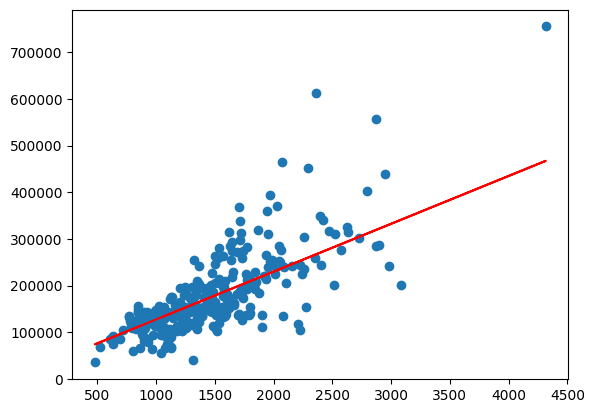

In [13]:
slr=LinearRegression()
slr.fit(X_train[['GrLivArea']],y_train)
pred=slr.predict(X_test[['GrLivArea']])
plt.scatter(X_test['GrLivArea'],y_test)
plt.plot(X_test['GrLivArea'],pred,color='red')
plt.show()

## Step 8 - Model Comparison

In [14]:
models={
'Linear':LinearRegression(),
'Ridge':Ridge(),
'Lasso':Lasso(max_iter=20000),
'ElasticNet':ElasticNet(max_iter=20000),
'DecisionTree':DecisionTreeRegressor(random_state=SEED),
'RandomForest':RandomForestRegressor(random_state=SEED),
'GradientBoosting':GradientBoostingRegressor(random_state=SEED)
}
rows=[]
for n,m in models.items():
    pipe=Pipeline([('prep',preprocess),('model',m)])
    pipe.fit(X_train,y_train)
    pr=pipe.predict(X_test)
    rows.append([n,
                 mean_absolute_error(y_test,pr),
                 np.sqrt(mean_squared_error(y_test,pr)),
                 r2_score(y_test,pr)])
results=pd.DataFrame(rows,columns=['Model','MAE','RMSE','R2']).sort_values('RMSE')
display(results)

,Model,MAE,RMSE,R2
6,GradientBoosting,16555.666542,26503.771884,0.908420
2,Lasso,17921.055465,28240.700495,0.896023
5,RandomForest,17408.137192,28432.111903,0.894609
0,Linear,18287.698623,29473.873055,0.886744
1,Ridge,19004.408494,29841.823697,0.883899
3,ElasticNet,20138.382432,36279.020403,0.828408
4,DecisionTree,26476.688356,41195.137254,0.778753


## Step 9 - Polynomial Regression

In [15]:
poly=Pipeline([
('imp',SimpleImputer(strategy='median')),
('poly',PolynomialFeatures(2,include_bias=False)),
('sc',StandardScaler()),
('ridge',Ridge())
])
poly.fit(X_train[['GrLivArea','OverallQual','YearBuilt']],y_train)
pp=poly.predict(X_test[['GrLivArea','OverallQual','YearBuilt']])
print(np.sqrt(mean_squared_error(y_test,pp)))

38526.15348208948


## Step 10 - Cross Validation & GridSearch

In [16]:
pipe=Pipeline([('prep',preprocess),('model',Ridge())])
cv=KFold(n_splits=5,shuffle=True,random_state=SEED)
print(cross_validate(pipe,X_train,y_train,cv=cv,scoring='neg_root_mean_squared_error')['test_score'].mean())
grid=GridSearchCV(pipe,{'model__alpha':[0.01,0.1,1,10,100]},cv=5,scoring='neg_root_mean_squared_error')
grid.fit(X_train,y_train)
best=grid.best_estimator_
print(grid.best_params_)

-32817.038111301765
{'model__alpha': 10}


## Step 11 - Residual Analysis

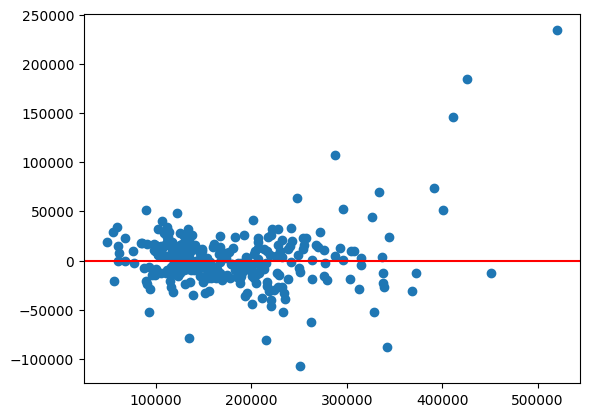

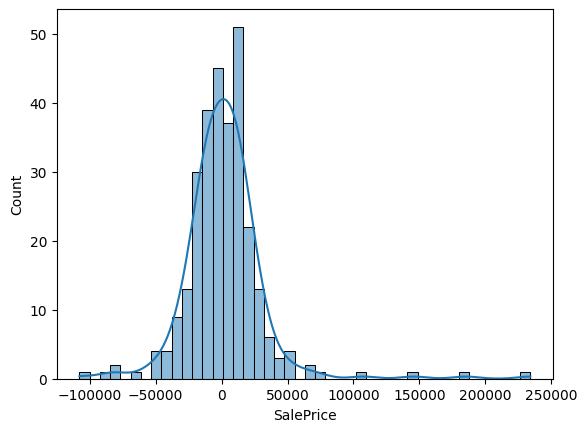

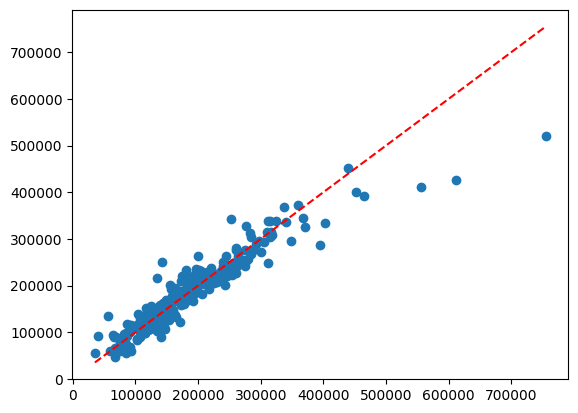

In [17]:
pred=best.predict(X_test)
res=y_test-pred
plt.scatter(pred,res);plt.axhline(0,color='r');plt.show()
sns.histplot(res,kde=True);plt.show()
plt.scatter(y_test,pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.show()

## Step 12 - Save

In [18]:
joblib.dump(best,'ames_pipeline.joblib')
results.to_csv('model_results.csv',index=False)
with open('metadata.json','w') as f:
    json.dump({'dataset':'Ames Housing','seed':42},f,indent=2)
print('Done')

Done
